# O dataset da Iris

![title](iris.png)


In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

import keras
from keras.models import Sequential
from keras.layers import Dense, Activation



import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
iris = load_iris()
iris.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
pd.DataFrame(iris['data'], columns=iris['feature_names'])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
pd.DataFrame(iris['target'], columns=['target'])  # tipos de iris



,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [5]:
iris['feature_names'] # características de iris

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
print(iris['data'].shape)
iris['data'][:10] #contêm as medidas de cada flor

(150, 4)


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [11]:
X, y = iris.data[:, :4], iris.target

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.5)

print('Shape de x_train', x_train.shape)
print('Shape de x_val', x_val.shape)
print('Shape de x_test', x_test.shape)

print('Shape de y_train', y_train.shape)
print('Shape de y_val', y_val.shape)
print('Shape de y_test', y_test.shape)


Shape de x_train (60, 4)
Shape de x_val (60, 4)
Shape de x_test (30, 4)
Shape de y_train (60,)
Shape de y_val (60,)
Shape de y_test (30,)


In [12]:
y_train

array([0, 2, 0, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 2,
       1, 2, 1, 0, 0, 2, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 1,
       2, 2, 1, 2, 1, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2])

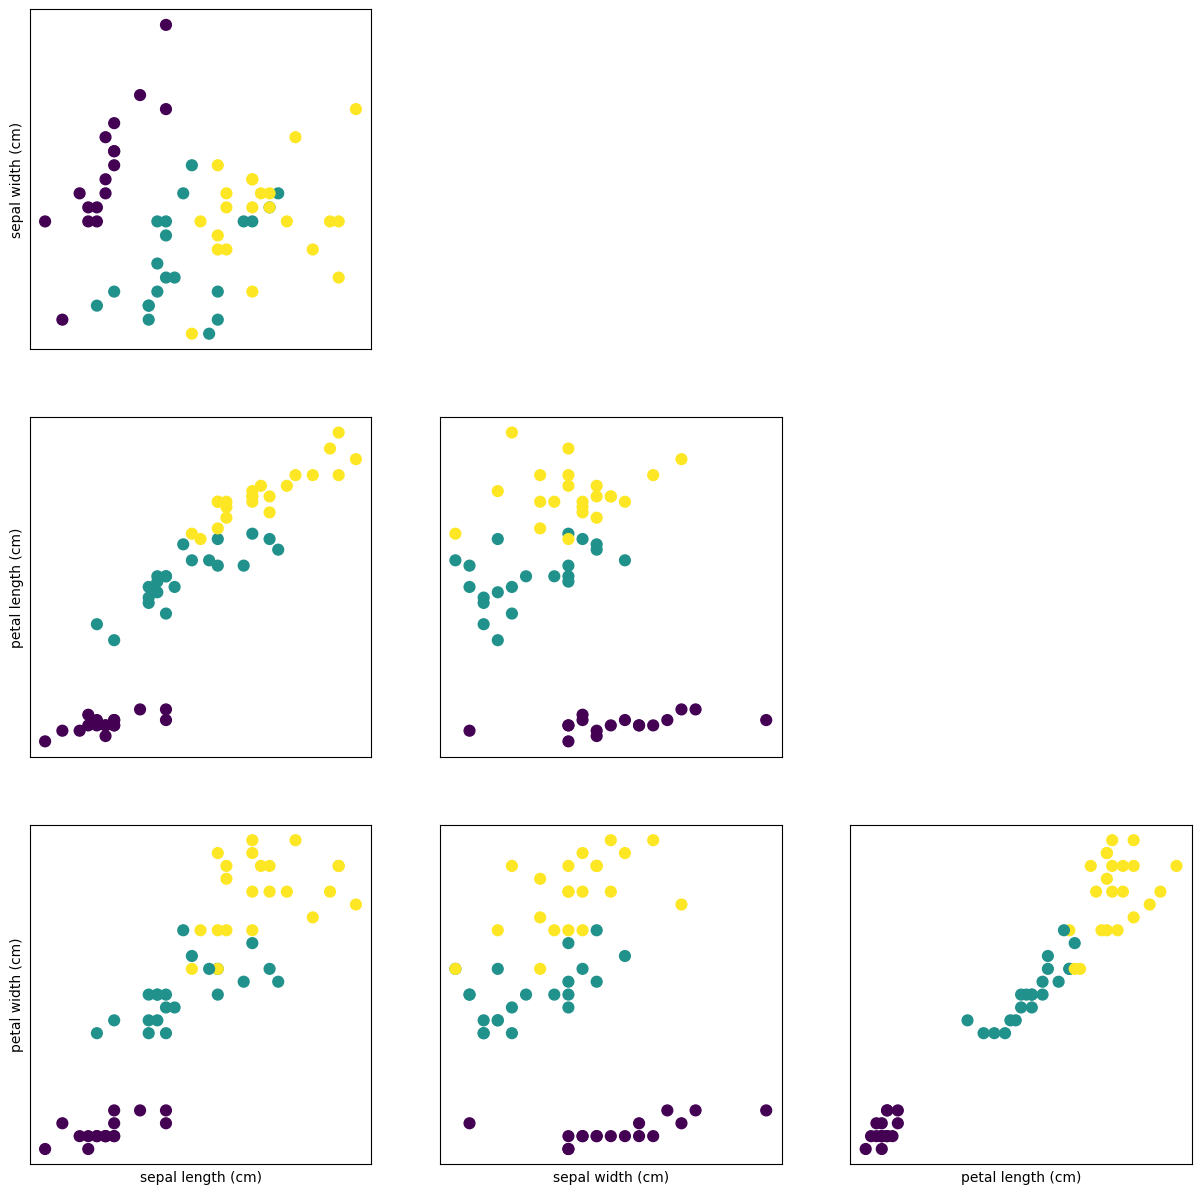

In [13]:
fig, ax = plt.subplots(3, 3, figsize=(15,15))

for i in range(3):
    for j in range(3):
        ax[i,j].scatter(x_train[:,j], x_train[:, i + 1], c=y_train, s=60)
        ax[i,j].set_xticks(())
        ax[i,j].set_yticks(())

        if i == 2:
            ax[i,j].set_xlabel(iris['feature_names'][j])
        if j == 0:
            ax[i,j].set_ylabel(iris['feature_names'][i + 1])
        if j > i:
            ax[i,j].set_visible(False)

In [14]:
model = Sequential()

# Layer de tamanho 16 e 4 atributos de flor (sepal x and y, petal x and y)
model.add(Dense(16, input_shape=(4,), activation='tanh'))
model.add(Dense(8, activation="relu"))
# 3 espécies de flor
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
batch_size = 16
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.2833 - loss: 1.5972 - val_accuracy: 0.3667 - val_loss: 1.2620
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2833 - loss: 1.4866 - val_accuracy: 0.3667 - val_loss: 1.1765
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2833 - loss: 1.3782 - val_accuracy: 0.4833 - val_loss: 1.1001
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4000 - loss: 1.2880 - val_accuracy: 0.6000 - val_loss: 1.0304
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5500 - loss: 1.1968 - val_accuracy: 0.6667 - val_loss: 0.9674
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6333 - loss: 1.1052 - val_accuracy: 0.7167 - val_loss: 0.9123
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6500 - loss: 1.0415 - val_accuracy: 0.7167 - val_loss: 0.8605
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6500 - loss: 0.9633 - val_accuracy: 0.7333 - val_loss:

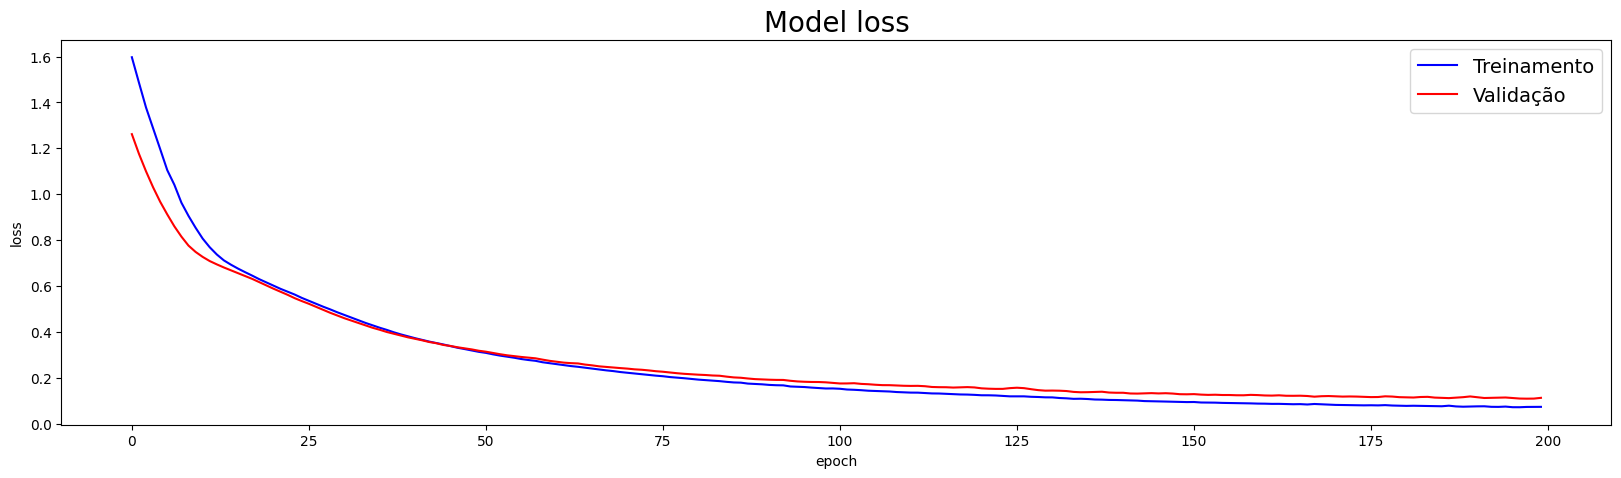

In [17]:
# Plotando o historico do processo de treinamento
plt.figure(figsize=(20, 5))
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.title('Model loss', fontsize=20)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Treinamento', 'Validação'], loc='upper right', fontsize=14)
plt.show()

In [18]:
#
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.05903426930308342
Test accuracy: 1.0


In [19]:
#testing model
x_new = np.array([[5, 2.9, 1, 0.2]])
x_new.shape

(1, 4)

In [20]:
prediction = model.predict(x_new)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[9.9349183e-01, 6.5043527e-03, 3.7762618e-06]], dtype=float32)

In [22]:
prediction.argmax()

np.int64(0)

In [23]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
iris['target_names'][prediction.argmax()]

np.str_('setosa')